In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()

REPORTS_DIR = PROJECT_ROOT / "results" / "reports"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
baseline_summary = pd.read_csv(REPORTS_DIR / "baseline_cnn_summary.csv")
mobilenet_summary = pd.read_csv(REPORTS_DIR / "mobilenetv2_summary.csv")
efficientnet_summary = pd.read_csv(REPORTS_DIR / "efficientnetb0_summary.csv")

display(baseline_summary)
display(mobilenet_summary)
display(efficientnet_summary)

,model_name,image_size,batch_size,epochs_requested,best_validation_accuracy,final_test_accuracy,final_test_loss,training_time_minutes,model_path
0,baseline_cnn,"(224, 224)",16,20,0.608898,0.755995,0.891662,11.867055,D:\MSC_PROJECT\experiments\01_baseline_cnn\bes...


,model_name,image_size,batch_size,initial_epochs,fine_tune_epochs,best_initial_validation_accuracy,best_finetuned_validation_accuracy,final_test_accuracy,final_test_loss,initial_training_time_minutes,fine_tuning_time_minutes,model_path
0,mobilenetv2_finetuned,"(224, 224)",16,10,10,0.622565,0.821169,0.846727,0.47684,13.033911,18.996937,D:\MSC_PROJECT\experiments\02_mobilenetv2\best...


,model_name,image_size,batch_size,initial_epochs,fine_tune_epochs,best_initial_validation_accuracy,best_finetuned_validation_accuracy,final_test_accuracy,final_test_loss,initial_training_time_minutes,fine_tuning_time_minutes,weights_path
0,efficientnetb0_finetuned,"(224, 224)",16,10,10,0.608316,0.722303,0.824692,0.543789,18.401494,19.168153,D:\MSC_PROJECT\experiments\03_efficientnet_b0\...


In [3]:
baseline_report = pd.read_csv(REPORTS_DIR / "baseline_cnn_classification_report.csv", index_col=0)
mobilenet_report = pd.read_csv(REPORTS_DIR / "mobilenetv2_classification_report.csv", index_col=0)
efficientnet_report = pd.read_csv(REPORTS_DIR / "efficientnetb0_classification_report.csv", index_col=0)

display(baseline_report.tail())
display(mobilenet_report.tail())
display(efficientnet_report.tail())

,precision,recall,f1-score,support
c8 - hair and makeup,0.521858,0.760956,0.619125,251.000000
c9 - talking to passenger,0.346369,0.480620,0.402597,258.000000
accuracy,0.755995,0.755995,0.755995,0.755995
macro avg,0.786608,0.747152,0.752705,3086.000000
weighted avg,0.802633,0.755995,0.765722,3086.000000


,precision,recall,f1-score,support
c8 - hair and makeup,0.631250,0.804781,0.707531,251.000000
c9 - talking to passenger,0.566540,0.577519,0.571977,258.000000
accuracy,0.846727,0.846727,0.846727,0.846727
macro avg,0.849458,0.840139,0.840137,3086.000000
weighted avg,0.861300,0.846727,0.849393,3086.000000


,precision,recall,f1-score,support
c8 - hair and makeup,0.502688,0.745020,0.600321,251.000000
c9 - talking to passenger,0.572093,0.476744,0.520085,258.000000
accuracy,0.824692,0.824692,0.824692,0.824692
macro avg,0.826648,0.815750,0.815791,3086.000000
weighted avg,0.841061,0.824692,0.827908,3086.000000


In [4]:
comparison_df = pd.DataFrame([
    {
        "model": "Baseline CNN",
        "validation_accuracy": baseline_summary.loc[0, "best_validation_accuracy"],
        "test_accuracy": baseline_summary.loc[0, "final_test_accuracy"],
        "macro_f1": baseline_report.loc["macro avg", "f1-score"],
        "weighted_f1": baseline_report.loc["weighted avg", "f1-score"],
        "training_time_minutes": baseline_summary.loc[0, "training_time_minutes"],
    },
    {
        "model": "MobileNetV2",
        "validation_accuracy": mobilenet_summary.loc[0, "best_finetuned_validation_accuracy"],
        "test_accuracy": mobilenet_summary.loc[0, "final_test_accuracy"],
        "macro_f1": mobilenet_report.loc["macro avg", "f1-score"],
        "weighted_f1": mobilenet_report.loc["weighted avg", "f1-score"],
        "training_time_minutes": (
            mobilenet_summary.loc[0, "initial_training_time_minutes"] +
            mobilenet_summary.loc[0, "fine_tuning_time_minutes"]
        ),
    },
    {
        "model": "EfficientNet-B0",
        "validation_accuracy": efficientnet_summary.loc[0, "best_finetuned_validation_accuracy"],
        "test_accuracy": efficientnet_summary.loc[0, "final_test_accuracy"],
        "macro_f1": efficientnet_report.loc["macro avg", "f1-score"],
        "weighted_f1": efficientnet_report.loc["weighted avg", "f1-score"],
        "training_time_minutes": (
            efficientnet_summary.loc[0, "initial_training_time_minutes"] +
            efficientnet_summary.loc[0, "fine_tuning_time_minutes"]
        ),
    }
])

display(comparison_df)

comparison_path = TABLES_DIR / "model_comparison_summary.csv"
comparison_df.to_csv(comparison_path, index=False)

print("Saved comparison table to:")
print(comparison_path)

,model,validation_accuracy,test_accuracy,macro_f1,weighted_f1,training_time_minutes
0,Baseline CNN,0.608898,0.755995,0.752705,0.765722,11.867055
1,MobileNetV2,0.821169,0.846727,0.840137,0.849393,32.030848
2,EfficientNet-B0,0.722303,0.824692,0.815791,0.827908,37.569647


Saved comparison table to:
D:\MSC_PROJECT\results\tables\model_comparison_summary.csv


In [5]:
comparison_percent_df = comparison_df.copy()

for col in ["validation_accuracy", "test_accuracy", "macro_f1", "weighted_f1"]:
    comparison_percent_df[col] = comparison_percent_df[col] * 100

display(comparison_percent_df)

comparison_percent_path = TABLES_DIR / "model_comparison_summary_percent.csv"
comparison_percent_df.to_csv(comparison_percent_path, index=False)

print("Saved percentage comparison table to:")
print(comparison_percent_path)

,model,validation_accuracy,test_accuracy,macro_f1,weighted_f1,training_time_minutes
0,Baseline CNN,60.889792,75.599480,75.270483,76.572196,11.867055
1,MobileNetV2,82.116896,84.672713,84.013731,84.939332,32.030848
2,EfficientNet-B0,72.230297,82.469213,81.579091,82.790838,37.569647


Saved percentage comparison table to:
D:\MSC_PROJECT\results\tables\model_comparison_summary_percent.csv


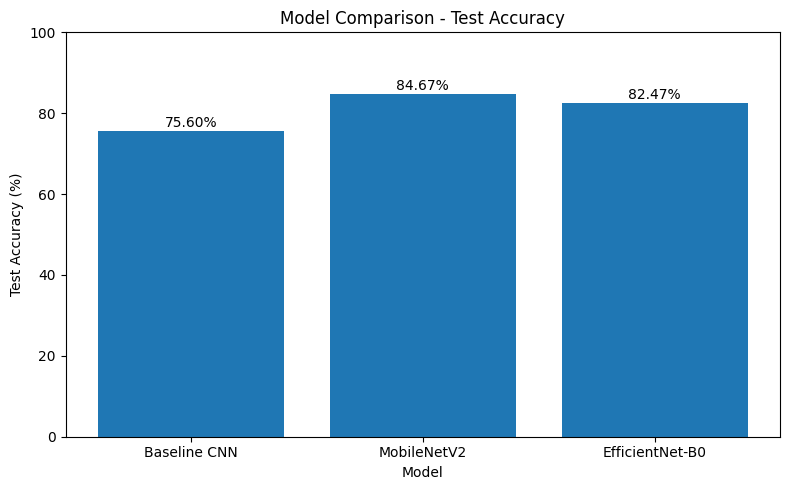

Saved accuracy chart to:
D:\MSC_PROJECT\results\figures\model_comparison_test_accuracy.png


In [6]:
plt.figure(figsize=(8, 5))

plt.bar(comparison_percent_df["model"], comparison_percent_df["test_accuracy"])

plt.title("Model Comparison - Test Accuracy")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 100)

for index, value in enumerate(comparison_percent_df["test_accuracy"]):
    plt.text(index, value + 1, f"{value:.2f}%", ha="center")

plt.tight_layout()

accuracy_chart_path = FIGURES_DIR / "model_comparison_test_accuracy.png"
plt.savefig(accuracy_chart_path, dpi=300)
plt.show()

print("Saved accuracy chart to:")
print(accuracy_chart_path)

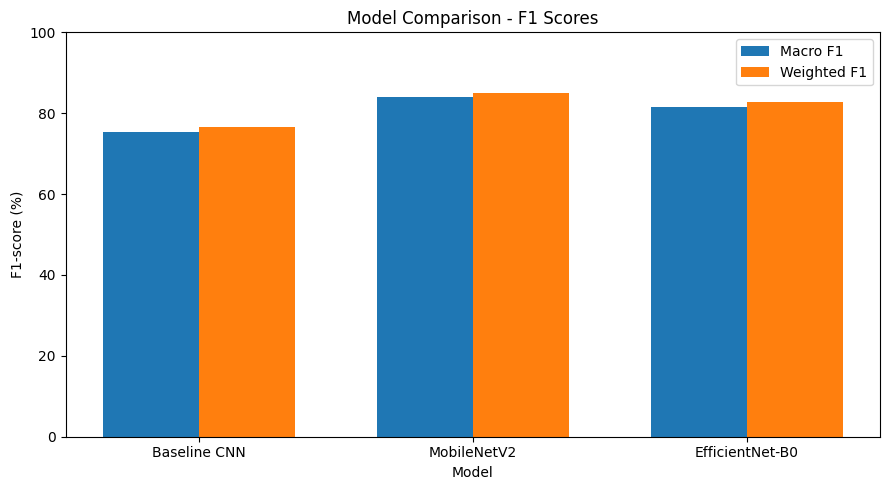

Saved F1 chart to:
D:\MSC_PROJECT\results\figures\model_comparison_f1_scores.png


In [7]:
plt.figure(figsize=(9, 5))

x = range(len(comparison_percent_df))
bar_width = 0.35

plt.bar(
    [i - bar_width / 2 for i in x],
    comparison_percent_df["macro_f1"],
    width=bar_width,
    label="Macro F1"
)

plt.bar(
    [i + bar_width / 2 for i in x],
    comparison_percent_df["weighted_f1"],
    width=bar_width,
    label="Weighted F1"
)

plt.title("Model Comparison - F1 Scores")
plt.xlabel("Model")
plt.ylabel("F1-score (%)")
plt.xticks(list(x), comparison_percent_df["model"])
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()

f1_chart_path = FIGURES_DIR / "model_comparison_f1_scores.png"
plt.savefig(f1_chart_path, dpi=300)
plt.show()

print("Saved F1 chart to:")
print(f1_chart_path)

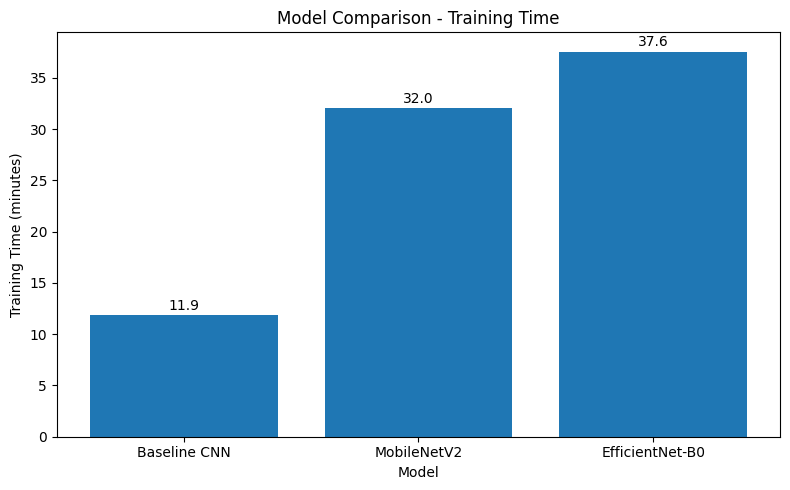

Saved training time chart to:
D:\MSC_PROJECT\results\figures\model_comparison_training_time.png


In [8]:
plt.figure(figsize=(8, 5))

plt.bar(comparison_df["model"], comparison_df["training_time_minutes"])

plt.title("Model Comparison - Training Time")
plt.xlabel("Model")
plt.ylabel("Training Time (minutes)")

for index, value in enumerate(comparison_df["training_time_minutes"]):
    plt.text(index, value + 0.5, f"{value:.1f}", ha="center")

plt.tight_layout()

time_chart_path = FIGURES_DIR / "model_comparison_training_time.png"
plt.savefig(time_chart_path, dpi=300)
plt.show()

print("Saved training time chart to:")
print(time_chart_path)

In [9]:
import tensorflow as tf
import numpy as np
import time
import os

from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
SPLIT_DIR = PROJECT_ROOT / "data" / "splits"

test_df = pd.read_csv(SPLIT_DIR / "state_farm_test_subject.csv")

IMG_SIZE = (224, 224)
BATCH_SIZE = 1
AUTOTUNE = tf.data.AUTOTUNE

def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def make_dataset(dataframe, batch_size=1):
    paths = dataframe["filepath"].astype(str).values
    labels = dataframe["label"].astype("int32").values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds

speed_test_ds = make_dataset(test_df, batch_size=1)

print("Speed test dataset ready.")
print("Test images:", len(test_df))

Speed test dataset ready.
Test images: 3086


In [10]:
def get_file_size_mb(path):
    path = Path(path)
    if path.exists():
        return path.stat().st_size / (1024 * 1024)
    return None

In [11]:
baseline_model_path = PROJECT_ROOT / "experiments" / "01_baseline_cnn" / "best_baseline_cnn.keras"
mobilenet_model_path = PROJECT_ROOT / "experiments" / "02_mobilenetv2" / "best_mobilenetv2_finetuned.keras"

baseline_model = tf.keras.models.load_model(baseline_model_path)
mobilenet_model = tf.keras.models.load_model(mobilenet_model_path)

print("Loaded Baseline CNN:", baseline_model_path)
print("Loaded MobileNetV2:", mobilenet_model_path)

print("Baseline model size MB:", get_file_size_mb(baseline_model_path))
print("MobileNetV2 model size MB:", get_file_size_mb(mobilenet_model_path))

Loaded Baseline CNN: D:\MSC_PROJECT\experiments\01_baseline_cnn\best_baseline_cnn.keras
Loaded MobileNetV2: D:\MSC_PROJECT\experiments\02_mobilenetv2\best_mobilenetv2_finetuned.keras
Baseline model size MB: 4.9563140869140625
MobileNetV2 model size MB: 20.782363891601562


In [18]:
def build_efficientnetb0_speed_model(input_shape=(224, 224, 3), num_classes=10):
    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.applications.efficientnet.preprocess_input(inputs)

    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name="efficientnetb0_speed_model")

    return model


efficientnet_model = build_efficientnetb0_speed_model(
    input_shape=IMG_SIZE + (3,),
    num_classes=10
)

efficientnet_weights_path = PROJECT_ROOT / "experiments" / "03_efficientnet_b0" / "best_efficientnetb0_finetuned.weights.h5"

print("EfficientNet-B0 speed model created.")
print("Using architecture for FPS measurement.")
print("Trained EfficientNet-B0 weights file size MB:", get_file_size_mb(efficientnet_weights_path))

EfficientNet-B0 speed model created.
Using architecture for FPS measurement.
Trained EfficientNet-B0 weights file size MB: 15.753875732421875


In [19]:
def measure_inference_speed(model, dataset, num_warmup=20, num_images=300):
    # Warm-up predictions
    for images, labels in dataset.take(num_warmup):
        _ = model.predict(images, verbose=0)

    start_time = time.time()

    count = 0
    for images, labels in dataset.take(num_images):
        _ = model.predict(images, verbose=0)
        count += images.shape[0]

    total_time = time.time() - start_time

    avg_time_per_image = total_time / count
    fps = count / total_time

    return {
        "num_images": count,
        "total_time_seconds": total_time,
        "avg_time_per_image_ms": avg_time_per_image * 1000,
        "fps": fps
    }

In [20]:
baseline_speed = measure_inference_speed(baseline_model, speed_test_ds)
mobilenet_speed = measure_inference_speed(mobilenet_model, speed_test_ds)
efficientnet_speed = measure_inference_speed(efficientnet_model, speed_test_ds)

print("Baseline CNN:", baseline_speed)
print("MobileNetV2:", mobilenet_speed)
print("EfficientNet-B0:", efficientnet_speed)

Baseline CNN: {'num_images': 300, 'total_time_seconds': 17.035683155059814, 'avg_time_per_image_ms': 56.78561051686605, 'fps': 17.610095073345867}
MobileNetV2: {'num_images': 300, 'total_time_seconds': 18.023837566375732, 'avg_time_per_image_ms': 60.07945855458578, 'fps': 16.64462403720633}
EfficientNet-B0: {'num_images': 300, 'total_time_seconds': 19.35304045677185, 'avg_time_per_image_ms': 64.51013485590616, 'fps': 15.501440234680363}


In [21]:
deployment_df = pd.DataFrame([
    {
        "model": "Baseline CNN",
        "test_accuracy": 75.599480,
        "weighted_f1": 76.572196,
        "model_size_mb": get_file_size_mb(baseline_model_path),
        "avg_inference_time_ms": baseline_speed["avg_time_per_image_ms"],
        "fps": baseline_speed["fps"],
        "speed_note": "trained model loaded"
    },
    {
        "model": "MobileNetV2",
        "test_accuracy": 84.672713,
        "weighted_f1": 84.939332,
        "model_size_mb": get_file_size_mb(mobilenet_model_path),
        "avg_inference_time_ms": mobilenet_speed["avg_time_per_image_ms"],
        "fps": mobilenet_speed["fps"],
        "speed_note": "trained model loaded"
    },
    {
        "model": "EfficientNet-B0",
        "test_accuracy": 82.469213,
        "weighted_f1": 82.790838,
        "model_size_mb": get_file_size_mb(efficientnet_weights_path),
        "avg_inference_time_ms": efficientnet_speed["avg_time_per_image_ms"],
        "fps": efficientnet_speed["fps"],
        "speed_note": "architecture speed measured; trained accuracy from saved evaluation"
    },
])

display(deployment_df)

deployment_path = TABLES_DIR / "model_deployment_comparison.csv"
deployment_df.to_csv(deployment_path, index=False)

print("Saved deployment comparison table to:")
print(deployment_path)

,model,test_accuracy,weighted_f1,model_size_mb,avg_inference_time_ms,fps,speed_note
0,Baseline CNN,75.599480,76.572196,4.956314,56.785611,17.610095,trained model loaded
1,MobileNetV2,84.672713,84.939332,20.782364,60.079459,16.644624,trained model loaded
2,EfficientNet-B0,82.469213,82.790838,15.753876,64.510135,15.501440,architecture speed measured; trained accuracy ...


Saved deployment comparison table to:
D:\MSC_PROJECT\results\tables\model_deployment_comparison.csv


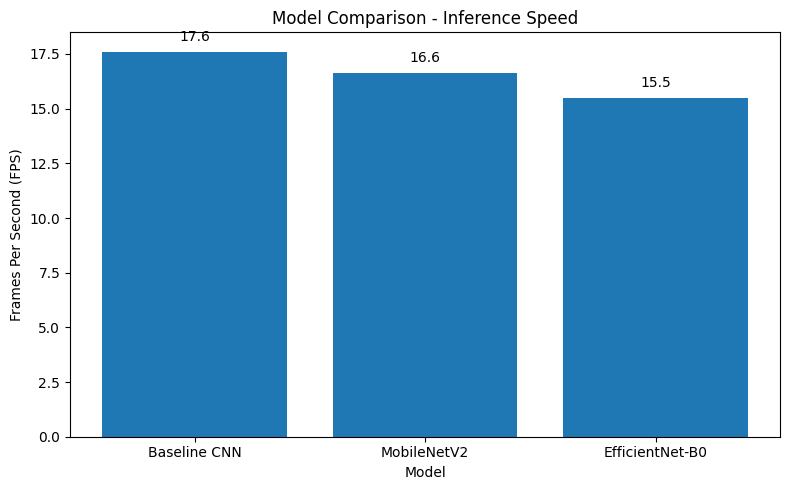

Saved FPS chart to:
D:\MSC_PROJECT\results\figures\model_comparison_fps.png


In [22]:
plt.figure(figsize=(8, 5))

plt.bar(deployment_df["model"], deployment_df["fps"])

plt.title("Model Comparison - Inference Speed")
plt.xlabel("Model")
plt.ylabel("Frames Per Second (FPS)")

for index, value in enumerate(deployment_df["fps"]):
    plt.text(index, value + 0.5, f"{value:.1f}", ha="center")

plt.tight_layout()

fps_chart_path = FIGURES_DIR / "model_comparison_fps.png"
plt.savefig(fps_chart_path, dpi=300)
plt.show()

print("Saved FPS chart to:")
print(fps_chart_path)

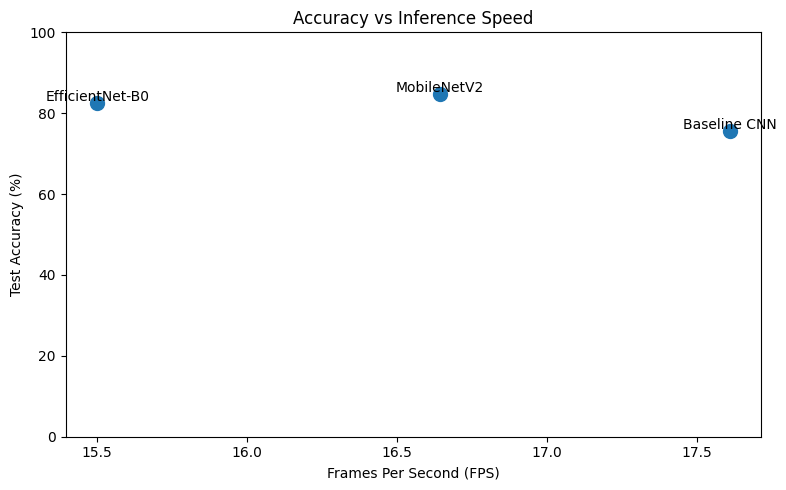

Saved accuracy vs FPS chart to:
D:\MSC_PROJECT\results\figures\accuracy_vs_fps_all_models.png


In [23]:
plt.figure(figsize=(8, 5))

plt.scatter(
    deployment_df["fps"],
    deployment_df["test_accuracy"],
    s=100
)

for _, row in deployment_df.iterrows():
    plt.text(
        row["fps"],
        row["test_accuracy"] + 0.5,
        row["model"],
        ha="center"
    )

plt.title("Accuracy vs Inference Speed")
plt.xlabel("Frames Per Second (FPS)")
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 100)

plt.tight_layout()

accuracy_fps_chart_path = FIGURES_DIR / "accuracy_vs_fps_all_models.png"
plt.savefig(accuracy_fps_chart_path, dpi=300)
plt.show()

print("Saved accuracy vs FPS chart to:")
print(accuracy_fps_chart_path)